In [ ]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     --- ------------------------------------ 10.2/114.6 kB ? eta -:--:--
     --- ------------------------------------ 10.2/114.6 kB ? eta -:--:--
     --- ------------------------------------ 10.2/114.6 kB ? eta -:--:--
     ------------- ----------------------- 41.0/114.6 kB 281.8 kB/s eta 0:00:01
     ------------------- ----------------- 61.4/114.6 kB 273.8 kB/s eta 0:00:01
     ------------------- ----------------- 61.4/114.6 kB 273.8 kB/s eta 0:00:01
     ------------------- ----------------- 61.4/114.6 kB 273.8 kB/s eta 0:00:01
     ------------------------------------ 114.6/114.6 kB 318.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     --------------------

In [ ]:
pip install pygame

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB 435.7 kB/s eta 0:00:25
   ---------------------------------------- 0.1/10.6 MB 563.7 kB/s eta 0:00:19
   ---------------------------------------- 0.1/10.6 MB 590.8 kB/s eta 0:00:18
    --------------------------------------- 0.2/10.6 MB 821.4 kB/s eta 0:00:13
    --------------------------------------- 0.2/10.6 MB 875.2 kB/s eta 0:00:12
   - -------------------------------------- 0.3/10.6 MB 999.9 kB/s eta 0:00:11
   - -------------------------------------- 0.5/10.6 MB 1.5 MB/s eta 0:00:07
   -- ------------------------------------- 0.7/10.6 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/10.6 MB 2.3 MB/s eta 0:00:05
   ----- ---------------------------------- 1.5/10.6 MB 3.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.2/10.6 MB 4.2 MB/s eta 0:00:02
 

In [ ]:
pip install numpy

In [ ]:
import time
import random
import heapq
import math
import matplotlib.pyplot as plt
import numpy as np
import pygame

In [ ]:
# We will assume 4-directional movement (N, S, E, W) with a cost of 1 per step.
def heuristic_manhattan(a, b):
    (x1, y1) = a
    (x2, y2) = b
    return abs(x1 - x2) + abs(y1 - y2)

def heuristic_euclidean(a, b):
    (x1, y1) = a
    (x2, y2) = b
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def heuristic_zero(a, b):
    return 0

# A mapping of heuristic names to their functions
HEURISTICS = {
    "Manhattan": heuristic_manhattan,
    "Euclidean": heuristic_euclidean,
    "Zero (Dijkstra)": heuristic_zero,
}

In [ ]:
def a_star_search(grid, start, goal, heuristic_func):
    width, height = len(grid[0]), len(grid)

    open_set = [(0 + heuristic_func(start, goal), 0, start)]
    heapq.heapify(open_set)

    came_from = {}

    g_score = { (x, y): float('inf') for y in range(height) for x in range(width) }
    g_score[start] = 0

    # Keep track of expanded nodes for performance comparison
    nodes_expanded = 0

    while open_set:
        # Get the node with the lowest f_score
        f, g, current = heapq.heappop(open_set)
        nodes_expanded += 1

        if current == goal:
            # Goal reached, reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1], nodes_expanded

        # Check neighbors (4-directional)
        for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            neighbor = (current[0] + dx, current[1] + dy)
            nx, ny = neighbor

            # Check bounds and obstacles
            if 0 <= nx < width and 0 <= ny < height and grid[ny][nx] == 0:
                # Cost to move to neighbor is 1
                tentative_g_score = g + 1

                if tentative_g_score < g_score[neighbor]:
                    # This is a better path to the neighbor
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    h_score = heuristic_func(neighbor, goal)
                    f_score = tentative_g_score + h_score
                    heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

    # No path found
    return None, nodes_expanded

In [ ]:
def create_random_grid(width, height, obstacle_density):
    grid = np.zeros((height, width), dtype=int)

    # Add obstacles
    for y in range(height):
        for x in range(width):
            if random.random() < obstacle_density:
                grid[y][x] = 1

    # Get a random free cell
    def get_free_cell():
        while True:
            x = random.randint(0, width - 1)
            y = random.randint(0, height - 1)
            if grid[y][x] == 0:
                return (x, y)

    start = get_free_cell()
    goal = get_free_cell()

    # Ensure start and goal are not the same
    while start == goal:
        goal = get_free_cell()

    return grid, start, goal

In [ ]:
def draw_grid(screen, grid, start, goal, path=None, visited=None):
    width, height = len(grid[0]), len(grid)
    CELL_SIZE = 20

    # Colors
    C_WHITE = (255, 255, 255)
    C_BLACK = (0, 0, 0)
    C_GREEN = (0, 255, 0)
    C_RED = (255, 0, 0)
    C_BLUE = (0, 0, 255)
    C_GRAY = (200, 200, 200)

    for y in range(height):
        for x in range(width):
            rect = (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE)
            color = C_WHITE
            if grid[y][x] == 1:
                color = C_BLACK

            pygame.draw.rect(screen, color, rect)
            pygame.draw.rect(screen, C_GRAY, rect, 1)

    # Draw path
    if path:
        for (x, y) in path[1:-1]:
            rect = (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE)
            pygame.draw.rect(screen, C_BLUE, rect)

    # Draw start and goal
    pygame.draw.rect(screen, C_GREEN, (start[0] * CELL_SIZE, start[1] * CELL_SIZE, CELL_SIZE, CELL_SIZE))
    pygame.draw.rect(screen, C_RED, (goal[0] * CELL_SIZE, goal[1] * CELL_SIZE, CELL_SIZE, CELL_SIZE))

    pygame.display.flip()


In [ ]:
def run_experiment(grid_size, obstacle_density, num_runs):
    results = {name: {"time": [], "nodes": [], "path_len": []} for name in HEURISTICS}
    print(f"--- Running Experiment (Size: {grid_size}, Runs: {num_runs}) ---")

    for i in range(num_runs):
        if (i + 1) % 10 == 0:
            print(f"Run {i + 1}/{num_runs}...")

        grid, start, goal = create_random_grid(grid_size, grid_size, obstacle_density)

        for name, func in HEURISTICS.items():
            start_time = time.perf_counter()
            path, nodes = a_star_search(grid, start, goal, func)
            end_time = time.perf_counter()

            if path:
                results[name]["time"].append(end_time - start_time)
                results[name]["nodes"].append(nodes)
                results[name]["path_len"].append(len(path))
            else:
                pass

    # Calculate averages
    avg_results = {}
    for name in HEURISTICS:
        avg_results[name] = {
            "avg_time": np.mean(results[name]["time"]),
            "avg_nodes": np.mean(results[name]["nodes"]),
            "avg_path_len": np.mean(results[name]["path_len"])
        }

    return avg_results

In [ ]:
def plot_results(avg_results):
    names = list(avg_results.keys())
    avg_times = [res["avg_time"] for res in avg_results.values()]
    avg_nodes = [res["avg_nodes"] for res in avg_results.values()]

    # Bar chart for Average Time
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.bar(names, avg_times, color=['blue', 'green', 'gray'])
    plt.title('Average Execution Time')
    plt.ylabel('Time (seconds)')
    plt.xticks(rotation=15)

    # Bar chart for Average Nodes Expanded
    plt.subplot(1, 2, 2)
    plt.bar(names, avg_nodes, color=['blue', 'green', 'gray'])
    plt.title('Average Nodes Expanded')
    plt.ylabel('Node Count')
    plt.xticks(rotation=15)

    plt.suptitle('A* Heuristic Performance Comparison')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the graph for your report
    plt.savefig("a_star_performance_comparison.png")
    print("\nGraph saved as 'a_star_performance_comparison.png'")
    plt.show()

--- Running Single A* Search (Manhattan) ---
Path found! Length: 26, Nodes expanded: 70
Path Coordinates:
[(29, 7), (28, 7), (27, 7), (27, 8), (27, 9), (27, 10), (27, 11), (27, 12), (27, 13), (26, 13), (25, 13), (24, 13), (23, 13), (22, 13), (21, 13), (20, 13), (19, 13), (18, 13), (17, 13), (16, 13), (16, 14), (16, 15), (16, 16), (15, 16), (14, 16), (13, 16)]

Initializing Pygame visualization...
Showing path animation... (Close window to continue to benchmark)
--- Running Experiment (Size: 50, Runs: 20) ---
Run 10/20...
Run 20/20...

--- Average Results ---
[Manhattan]
  Avg. Time:  0.001735 s
  Avg. Nodes: 268.63
  Avg. Path:  40.32
[Euclidean]
  Avg. Time:  0.002056 s
  Avg. Nodes: 420.26
  Avg. Path:  40.32
[Zero (Dijkstra)]
  Avg. Time:  0.004933 s
  Avg. Nodes: 1168.32
  Avg. Path:  40.32

Graph saved as 'a_star_performance_comparison.png'


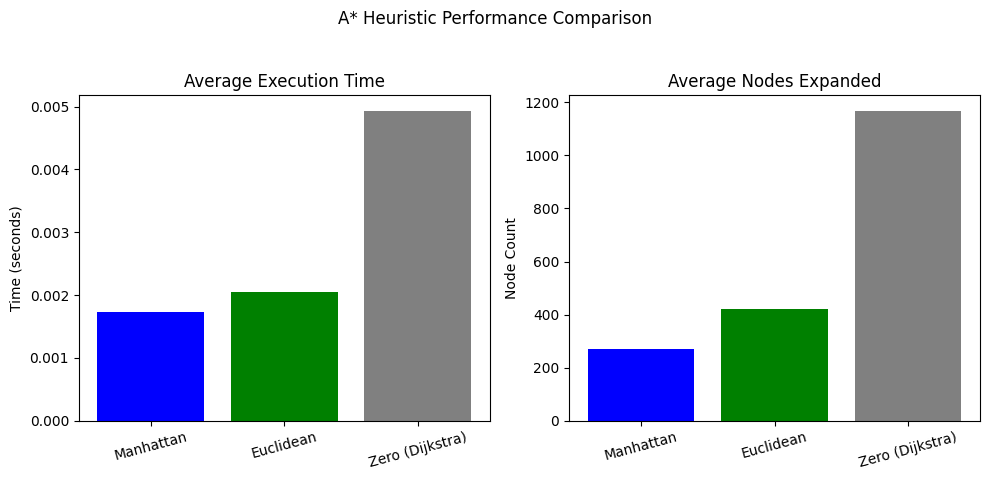

In [ ]:
if __name__ == "__main__":

    GRID_W, GRID_H = 30, 30
    OBSTACLE_DENSITY = 0.2

    print("--- Running Single A* Search (Manhattan) ---")
    grid, start, goal = create_random_grid(GRID_W, GRID_H, OBSTACLE_DENSITY)

    path, nodes = a_star_search(grid, start, goal, heuristic_manhattan)

    if path:
        print(f"Path found! Length: {len(path)}, Nodes expanded: {nodes}")
        print("Path Coordinates:")
        print(path)
    else:
        print(f"No path found. Nodes expanded: {nodes}")

    print("\nInitializing Pygame visualization...")
    print("Showing path animation... (Close window to continue to benchmark)")

    pygame.init()
    screen = pygame.display.set_mode((GRID_W * 20, GRID_H * 20))
    pygame.display.set_caption("A* Path-finding Animation")


    # This loop will run the animation
    running = True
    if path:
        for i in range(1, len(path) + 1):
            if not running:
                break
            current_path_segment = path[:i]
            draw_grid(screen, grid, start, goal, current_path_segment)
            pygame.time.wait(50)

            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    running = False
        if running:
            draw_grid(screen, grid, start, goal, path)

    else:
        draw_grid(screen, grid, start, goal, None)

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
    pygame.quit()

    NUM_RUNS = 20
    GRID_SIZE = 50
    OBSTACLE_DENSITY = 0.2

    avg_data = run_experiment(GRID_SIZE, OBSTACLE_DENSITY, NUM_RUNS)

    print("\n--- Average Results ---")
    for name, data in avg_data.items():
        print(f"[{name}]")
        print(f"  Avg. Time:  {data['avg_time']:.6f} s")
        print(f"  Avg. Nodes: {data['avg_nodes']:.2f}")
        print(f"  Avg. Path:  {data['avg_path_len']:.2f}")

    plot_results(avg_data)